In [85]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.linear_model import SGDRegressor


In [86]:
# Cargar los datos
df2 = pd.read_csv('cash request.csv')
df = df2.copy()
# Convertir las columnas de fecha a formato datetime
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['moderated_at'] = pd.to_datetime(df['moderated_at'], errors='coerce')

# Calcular la diferencia de tiempo en horas
df['moderated-created'] = (df['moderated_at'] - df['created_at']).dt.total_seconds() / 3600  # Convertir a horas
# Calcular la diferencia de tiempo SOLO para los registros con status 'rejected'
mask = df['status'] == 'rejected'
df.loc[mask, 'time_to_reject'] = (df.loc[mask, 'moderated_at'] - df.loc[mask, 'created_at']).dt.total_seconds() / 3600  # Convertir a horas

# Mostrar las primeras filas con la nueva columna
df


,id,amount,status,created_at,updated_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update,moderated-created,time_to_reject
0,5,100.0,rejected,2019-12-10 19:05:21.596873+00:00,2019-12-11 16:47:42.40783+00,804.0,2019-12-11 16:47:42.405646+00:00,NaN,2020-01-09 19:05:21.596363+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,21.705780,21.705780
1,70,100.0,rejected,2019-12-10 19:50:12.347780+00:00,2019-12-11 14:24:22.900054+00,231.0,2019-12-11 14:24:22.897988+00:00,NaN,2020-01-09 19:50:12.34778+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,18.569597,18.569597
2,7,100.0,rejected,2019-12-10 19:13:35.825460+00:00,2019-12-11 09:46:59.779773+00,191.0,2019-12-11 09:46:59.777728+00:00,NaN,2020-01-09 19:13:35.825041+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,14.556653,14.556653
3,10,99.0,rejected,2019-12-10 19:16:10.880172+00:00,2019-12-18 14:26:18.136163+00,761.0,2019-12-18 14:26:18.128407+00:00,NaN,2020-01-09 19:16:10.879606+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,187.168680,187.168680
4,1594,100.0,rejected,2020-05-06 09:59:38.877376+00:00,2020-05-07 09:21:55.34008+00,7686.0,2020-05-07 09:21:55.320193+00:00,NaN,2020-06-05 22:00:00+00,NaN,NaN,regular,NaN,NaN,NaN,NaN,23.371234,23.371234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,20616,100.0,money_back,2020-10-12 13:54:11.686225+00:00,2021-02-06 20:17:49.292493+00,13681.0,NaT,NaN,2021-02-06 11:00:00+00,2020-10-13,2021-02-06 20:17:49.257521+00,instant,2020-10-12 13:54:24.352856+00,NaN,NaN,NaN,NaN,NaN
23966,25243,50.0,money_back,2020-10-27 14:41:25.734910+00:00,2020-12-18 13:15:40.843946+00,NaN,NaT,30367.0,2020-11-03 22:00:00+00,2020-10-28,2020-12-01 13:26:53.787672+00,instant,2020-10-27 14:41:57.901946+00,completed,2020-11-12 23:20:41.928788+00,2020-12-01 13:26:53.815504+00,NaN,NaN
23967,22357,100.0,money_back,2020-10-20 07:58:04.006937+00:00,2021-02-05 12:19:30.656816+00,82122.0,NaT,NaN,2021-02-05 11:00:00+00,2020-10-21,2021-02-05 12:19:30.626289+00,instant,2020-10-20 07:58:14.171553+00,NaN,NaN,NaN,NaN,NaN
23968,20256,100.0,money_back,2020-10-10 05:40:55.700422+00:00,2021-02-05 13:14:19.707627+00,64517.0,NaT,NaN,2021-02-05 11:00:00+00,2020-10-12,2021-02-05 13:14:19.689906+00,instant,2020-10-10 05:41:23.368363+00,NaN,NaN,NaN,NaN,NaN


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23970 entries, 0 to 23969
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype              
---  ------                      --------------  -----              
 0   id                          23970 non-null  int64              
 1   amount                      23970 non-null  float64            
 2   status                      23970 non-null  object             
 3   created_at                  23970 non-null  datetime64[ns, UTC]
 4   updated_at                  23970 non-null  object             
 5   user_id                     21867 non-null  float64            
 6   moderated_at                15912 non-null  datetime64[ns, UTC]
 7   deleted_account_id          2104 non-null   float64            
 8   reimbursement_date          23970 non-null  object             
 9   cash_request_received_date  16289 non-null  object             
 10  money_back_date             16543 non-null  object        

In [88]:
date_columns = ['created_at', 'moderated_at', 'updated_at', 'reimbursement_date',
                'cash_request_debited_date', 'cash_request_received_date',
                'money_back_date', 'send_at', 'reco_creation', 'reco_last_update']

# Verificar qué columnas existen en el DataFrame antes de convertirlas
existing_date_columns = [col for col in date_columns if col in df.columns]

# Aplicar el formato YYYY-MM-DD a las columnas de fecha existentes
df[existing_date_columns] = df[existing_date_columns].apply(pd.to_datetime, errors='coerce')
df[existing_date_columns] = df[existing_date_columns].apply(lambda x: x.dt.strftime('%Y-%m-%d'))

# Mostrar las primeras filas con las fechas en el nuevo formato
df.head()

,id,amount,status,created_at,updated_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,recovery_status,reco_creation,reco_last_update,moderated-created,time_to_reject
0,5,100.0,rejected,2019-12-10,2019-12-11,804.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,NaN,NaN,NaN,21.705780,21.705780
1,70,100.0,rejected,2019-12-10,2019-12-11,231.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,NaN,NaN,NaN,18.569597,18.569597
2,7,100.0,rejected,2019-12-10,2019-12-11,191.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,NaN,NaN,NaN,14.556653,14.556653
3,10,99.0,rejected,2019-12-10,2019-12-18,761.0,2019-12-18,NaN,2020-01-09,NaN,NaN,regular,NaN,NaN,NaN,NaN,187.168680,187.168680
4,1594,100.0,rejected,2020-05-06,2020-05-07,7686.0,2020-05-07,NaN,NaN,NaN,NaN,regular,NaN,NaN,NaN,NaN,23.371234,23.371234


In [89]:
df['updated_at'] = pd.to_datetime(df['updated_at'], errors='coerce')
df['moderated_at'] = pd.to_datetime(df['moderated_at'], errors='coerce')

# Contar cuántas veces son iguales
count_equal = (df['updated_at'] == df['moderated_at']).sum()

# Mostrar el resultado
print(f"Número de veces que 'updated_at' y 'moderated_at' son iguales: {count_equal}")

Número de veces que 'updated_at' y 'moderated_at' son iguales: 6502


En todos los casos donde son iguales, el estado es rejected.

In [90]:
df = df.drop(columns=['recovery_status', 'reco_creation', 'reco_last_update', 'updated_at'])
df

,id,amount,status,created_at,user_id,moderated_at,deleted_account_id,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,moderated-created,time_to_reject
0,5,100.0,rejected,2019-12-10,804.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,21.705780,21.705780
1,70,100.0,rejected,2019-12-10,231.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,18.569597,18.569597
2,7,100.0,rejected,2019-12-10,191.0,2019-12-11,NaN,2020-01-09,NaN,NaN,regular,NaN,14.556653,14.556653
3,10,99.0,rejected,2019-12-10,761.0,2019-12-18,NaN,2020-01-09,NaN,NaN,regular,NaN,187.168680,187.168680
4,1594,100.0,rejected,2020-05-06,7686.0,2020-05-07,NaN,NaN,NaN,NaN,regular,NaN,23.371234,23.371234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,20616,100.0,money_back,2020-10-12,13681.0,NaT,NaN,NaN,2020-10-13,2021-02-06,instant,2020-10-12,NaN,NaN
23966,25243,50.0,money_back,2020-10-27,NaN,NaT,30367.0,NaN,2020-10-28,2020-12-01,instant,2020-10-27,NaN,NaN
23967,22357,100.0,money_back,2020-10-20,82122.0,NaT,NaN,NaN,2020-10-21,2021-02-05,instant,2020-10-20,NaN,NaN
23968,20256,100.0,money_back,2020-10-10,64517.0,NaT,NaN,NaN,2020-10-12,2021-02-05,instant,2020-10-10,NaN,NaN


In [91]:
df.fillna({"user_id": df["deleted_account_id"]}, inplace=True)

In [92]:
df.drop(columns=["deleted_account_id"], inplace=True)

In [93]:
df

,id,amount,status,created_at,user_id,moderated_at,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,moderated-created,time_to_reject
0,5,100.0,rejected,2019-12-10,804.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,21.705780,21.705780
1,70,100.0,rejected,2019-12-10,231.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,18.569597,18.569597
2,7,100.0,rejected,2019-12-10,191.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,14.556653,14.556653
3,10,99.0,rejected,2019-12-10,761.0,2019-12-18,2020-01-09,NaN,NaN,regular,NaN,187.168680,187.168680
4,1594,100.0,rejected,2020-05-06,7686.0,2020-05-07,NaN,NaN,NaN,regular,NaN,23.371234,23.371234
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23965,20616,100.0,money_back,2020-10-12,13681.0,NaT,NaN,2020-10-13,2021-02-06,instant,2020-10-12,NaN,NaN
23966,25243,50.0,money_back,2020-10-27,30367.0,NaT,NaN,2020-10-28,2020-12-01,instant,2020-10-27,NaN,NaN
23967,22357,100.0,money_back,2020-10-20,82122.0,NaT,NaN,2020-10-21,2021-02-05,instant,2020-10-20,NaN,NaN
23968,20256,100.0,money_back,2020-10-10,64517.0,NaT,NaN,2020-10-12,2021-02-05,instant,2020-10-10,NaN,NaN


COHORTES

In [94]:
df['created_at'] = pd.to_datetime(df['created_at'])
df['semana'] = df['created_at'].dt.to_period('W')  # Convertir a períodos semanales
df['semana_inicio'] = df['semana'].dt.to_timestamp()

df['created_at'] = df['created_at'].dt.to_period('M')

In [95]:
df['Cohorte'] = df.groupby('user_id')['semana'].transform('min')
df.head()

,id,amount,status,created_at,user_id,moderated_at,reimbursement_date,cash_request_received_date,money_back_date,transfer_type,send_at,moderated-created,time_to_reject,semana,semana_inicio,Cohorte
0,5,100.0,rejected,2019-12,804.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,21.705780,21.705780,2019-12-09/2019-12-15,2019-12-09,2019-12-09/2019-12-15
1,70,100.0,rejected,2019-12,231.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,18.569597,18.569597,2019-12-09/2019-12-15,2019-12-09,2019-12-09/2019-12-15
2,7,100.0,rejected,2019-12,191.0,2019-12-11,2020-01-09,NaN,NaN,regular,NaN,14.556653,14.556653,2019-12-09/2019-12-15,2019-12-09,2019-12-09/2019-12-15
3,10,99.0,rejected,2019-12,761.0,2019-12-18,2020-01-09,NaN,NaN,regular,NaN,187.168680,187.168680,2019-12-09/2019-12-15,2019-12-09,2019-12-09/2019-12-15
4,1594,100.0,rejected,2020-05,7686.0,2020-05-07,NaN,NaN,NaN,regular,NaN,23.371234,23.371234,2020-05-04/2020-05-10,2020-05-04,2020-05-04/2020-05-10


In [96]:
cohorte_amount_week = df.groupby(['Cohorte','semana']).agg(Amount=('amount', 'sum')).reset_index()
cohorte_amount_week

,Cohorte,semana,Amount
0,2019-11-18/2019-11-24,2019-11-18/2019-11-24,1.0
1,2019-11-18/2019-11-24,2019-12-09/2019-12-15,100.0
2,2019-11-18/2019-11-24,2020-04-13/2020-04-19,100.0
3,2019-11-18/2019-11-24,2020-05-11/2020-05-17,10.0
4,2019-11-18/2019-11-24,2020-08-03/2020-08-09,10.0
...,...,...,...
1001,2020-10-12/2020-10-18,2020-10-19/2020-10-25,425.0
1002,2020-10-12/2020-10-18,2020-10-26/2020-11-01,2930.0
1003,2020-10-19/2020-10-25,2020-10-19/2020-10-25,120989.0
1004,2020-10-19/2020-10-25,2020-10-26/2020-11-01,3335.0


In [97]:
cohort_sizes_initial = cohorte_amount_week.groupby('Cohorte').first()
cohort_sizes_initial


,semana,Amount
Cohorte,,
2019-11-18/2019-11-24,2019-11-18/2019-11-24,1.0
2019-12-09/2019-12-15,2019-12-09/2019-12-15,10026.0
2019-12-16/2019-12-22,2019-12-16/2019-12-22,10321.0
2019-12-23/2019-12-29,2019-12-23/2019-12-29,3180.0
2019-12-30/2020-01-05,2019-12-30/2020-01-05,1300.0
2020-01-06/2020-01-12,2020-01-06/2020-01-12,2900.0
2020-01-13/2020-01-19,2020-01-13/2020-01-19,1050.0
2020-01-20/2020-01-26,2020-01-20/2020-01-26,1200.0
2020-01-27/2020-02-02,2020-01-27/2020-02-02,5406.0


In [98]:
cohorte = cohorte_amount_week.pivot(index='Cohorte',
columns='semana',
values='Amount')
cohorte

semana,2019-11-18/2019-11-24,2019-12-09/2019-12-15,2019-12-16/2019-12-22,2019-12-23/2019-12-29,2019-12-30/2020-01-05,2020-01-06/2020-01-12,2020-01-13/2020-01-19,2020-01-20/2020-01-26,2020-01-27/2020-02-02,2020-02-03/2020-02-09,...,2020-08-24/2020-08-30,2020-08-31/2020-09-06,2020-09-07/2020-09-13,2020-09-14/2020-09-20,2020-09-21/2020-09-27,2020-09-28/2020-10-04,2020-10-05/2020-10-11,2020-10-12/2020-10-18,2020-10-19/2020-10-25,2020-10-26/2020-11-01
Cohorte,,,,,,,,,,,,,,,,,,,,,
2019-11-18/2019-11-24,1.0,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,5.0,NaN,NaN,5.0,NaN,1.0
2019-12-09/2019-12-15,NaN,10026.0,770.0,810.0,1050.0,1320.0,1515.0,460.0,870.0,650.0,...,150.0,650.0,1000.0,450.0,400.0,100.0,450.0,1130.0,300.0,350.0
2019-12-16/2019-12-22,NaN,NaN,10321.0,550.0,1190.0,1250.0,700.0,860.0,448.0,801.0,...,300.0,600.0,900.0,210.0,NaN,200.0,950.0,650.0,275.0,550.0
2019-12-23/2019-12-29,NaN,NaN,NaN,3180.0,100.0,200.0,300.0,200.0,300.0,400.0,...,NaN,350.0,NaN,300.0,50.0,100.0,500.0,650.0,150.0,150.0
2019-12-30/2020-01-05,NaN,NaN,NaN,NaN,1300.0,200.0,NaN,100.0,100.0,200.0,...,NaN,100.0,300.0,50.0,NaN,100.0,250.0,NaN,NaN,NaN
2020-01-06/2020-01-12,NaN,NaN,NaN,NaN,NaN,2900.0,100.0,200.0,498.0,300.0,...,200.0,NaN,200.0,100.0,NaN,NaN,100.0,100.0,100.0,250.0
2020-01-13/2020-01-19,NaN,NaN,NaN,NaN,NaN,NaN,1050.0,NaN,80.0,180.0,...,100.0,50.0,NaN,NaN,100.0,NaN,100.0,100.0,NaN,200.0
2020-01-20/2020-01-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1200.0,300.0,200.0,...,NaN,260.0,60.0,NaN,50.0,100.0,NaN,150.0,NaN,100.0
2020-01-27/2020-02-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5406.0,600.0,...,NaN,400.0,200.0,300.0,350.0,100.0,200.0,450.0,200.0,200.0


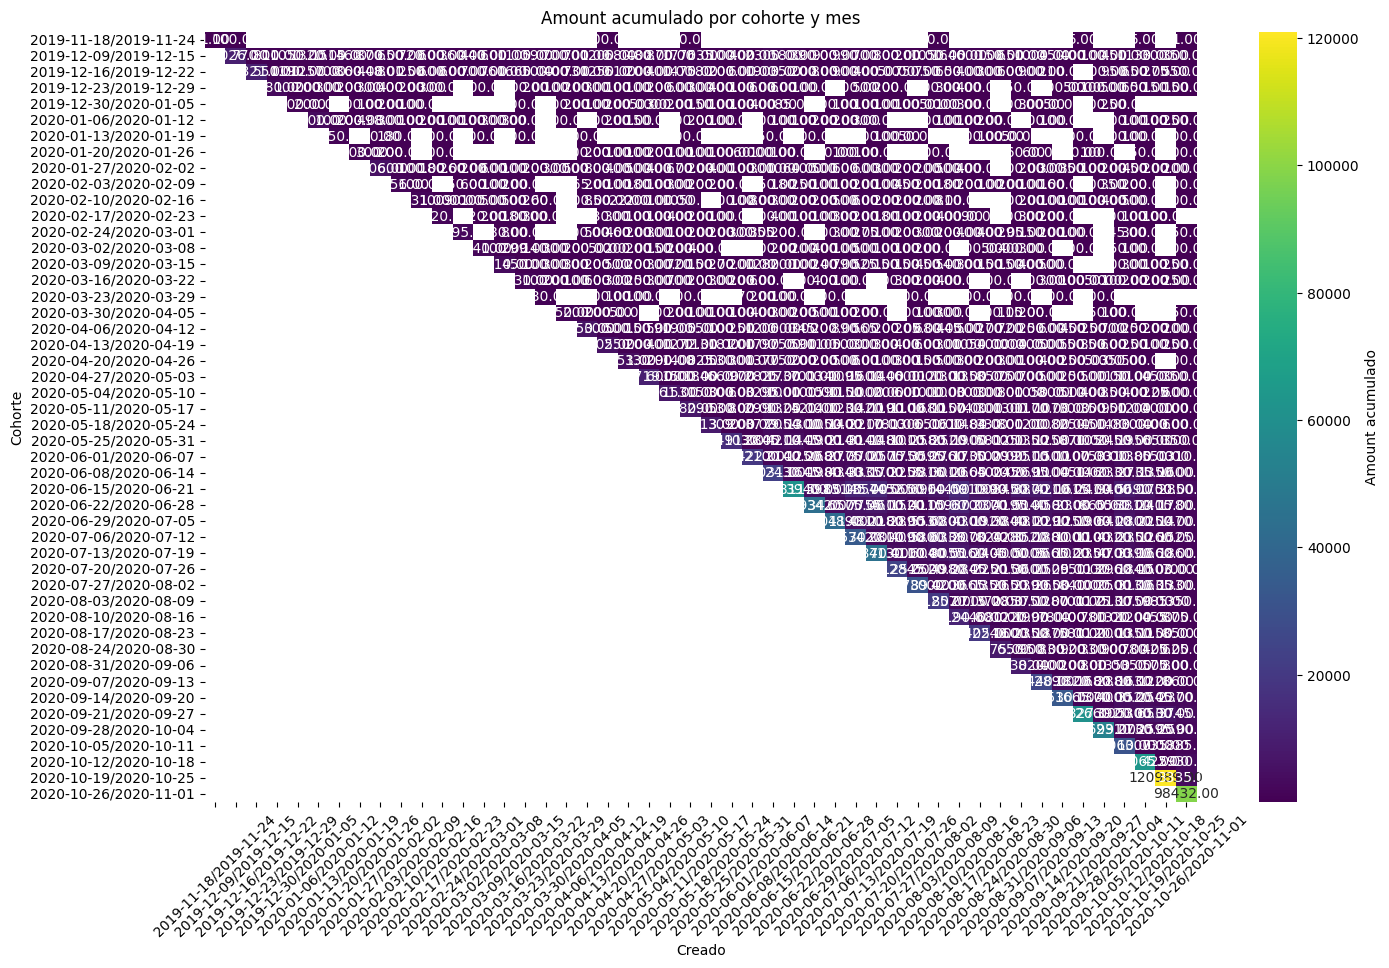

In [99]:
plt.figure(figsize=(16, 10))
plt.title('Amount acumulado por cohorte y mes')
sns.heatmap(data=cohorte, annot=True, fmt='.2f',
cmap='viridis', cbar_kws={'label': 'Amount acumulado'})
plt.xlabel('Creado')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.ylabel('Cohorte')
plt.show()

In [100]:
cohorte.columns

PeriodIndex(['2019-11-18/2019-11-24', '2019-12-09/2019-12-15',
             '2019-12-16/2019-12-22', '2019-12-23/2019-12-29',
             '2019-12-30/2020-01-05', '2020-01-06/2020-01-12',
             '2020-01-13/2020-01-19', '2020-01-20/2020-01-26',
             '2020-01-27/2020-02-02', '2020-02-03/2020-02-09',
             '2020-02-10/2020-02-16', '2020-02-17/2020-02-23',
             '2020-02-24/2020-03-01', '2020-03-02/2020-03-08',
             '2020-03-09/2020-03-15', '2020-03-16/2020-03-22',
             '2020-03-23/2020-03-29', '2020-03-30/2020-04-05',
             '2020-04-06/2020-04-12', '2020-04-13/2020-04-19',
             '2020-04-20/2020-04-26', '2020-04-27/2020-05-03',
             '2020-05-04/2020-05-10', '2020-05-11/2020-05-17',
             '2020-05-18/2020-05-24', '2020-05-25/2020-05-31',
             '2020-06-01/2020-06-07', '2020-06-08/2020-06-14',
             '2020-06-15/2020-06-21', '2020-06-22/2020-06-28',
             '2020-06-29/2020-07-05', '2020-07-06/2020-

In [101]:
fila2 = cohorte.loc['2019-12-09':'2019-12-15'].T
fila2

Cohorte,2019-12-09/2019-12-15
semana,
2019-11-18/2019-11-24,NaN
2019-12-09/2019-12-15,10026.0
2019-12-16/2019-12-22,770.0
2019-12-23/2019-12-29,810.0
2019-12-30/2020-01-05,1050.0
2020-01-06/2020-01-12,1320.0
2020-01-13/2020-01-19,1515.0
2020-01-20/2020-01-26,460.0
2020-01-27/2020-02-02,870.0


In [102]:
df_no_nulos = fila2.dropna().reset_index()


# Renombrar columnas si es necesario
df_no_nulos.columns = ["semana", "Acumulado"]

# Verificar la estructura
print(df_no_nulos.head())


                  semana  Acumulado
0  2019-12-09/2019-12-15    10026.0
1  2019-12-16/2019-12-22      770.0
2  2019-12-23/2019-12-29      810.0
3  2019-12-30/2020-01-05     1050.0
4  2020-01-06/2020-01-12     1320.0


In [103]:
# Asegurar que ambas listas tienen la misma longitud
if len(df_no_nulos["semana"]) == len(df_no_nulos["Acumulado"]):
    print("Las listas están alineadas correctamente.")
else:
    print("Hay un desajuste en la cantidad de datos.")

# Asegurar que ambas listas están estructuradas como columnas de un DataFrame sin valores desalineados
df_no_nulos = df_no_nulos.dropna().reset_index(drop=True)

# Mostrar el DataFrame corregido

Las listas están alineadas correctamente.


In [104]:
df_no_nulos


,semana,Acumulado
0,2019-12-09/2019-12-15,10026.0
1,2019-12-16/2019-12-22,770.0
2,2019-12-23/2019-12-29,810.0
3,2019-12-30/2020-01-05,1050.0
4,2020-01-06/2020-01-12,1320.0
5,2020-01-13/2020-01-19,1515.0
6,2020-01-20/2020-01-26,460.0
7,2020-01-27/2020-02-02,870.0
8,2020-02-03/2020-02-09,650.0
9,2020-02-10/2020-02-16,720.0


In [105]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def graficar_ingresos_polinomicos_semanal(df_no_nulos, grado, alpha=1.0):
    """
    Graficar la regresión polinómica de los ingresos acumulados de una cohorte específica con regularización Ridge.

    Args:
        df_no_nulos (DataFrame): DataFrame con las semanas y valores acumulados.
        grado (int): Grado del polinomio para la regresión.
        alpha (float): Parámetro de regularización de Ridge.
    """

    # Eliminar la primera semana (2019-12-09/2019-12-15) si está presente
    df_no_nulos = df_no_nulos[df_no_nulos['semana'] != '2019-12-09/2019-12-15']

    # Separar los datos en 80% interpolación y 20% extrapolación
    num_interpolacion = int(0.8 * len(df_no_nulos))
    df_interpolacion = df_no_nulos.iloc[:num_interpolacion]
    df_extrapolacion = df_no_nulos.iloc[num_interpolacion:]

    # Separar el 80% de interpolación en 80% entrenamiento y 20% prueba
    X_interpolacion = df_interpolacion[['semana']].astype(int).values.ravel()
    y_interpolacion = df_interpolacion['Acumulado'].values

    X_train, X_test, y_train, y_test = train_test_split(X_interpolacion, y_interpolacion, test_size=0.2, random_state=42)

    # Normalizar los datos

    X_train_scaled = X_train.reshape(-1, 1)
    X_test_scaled = X_test.reshape(-1, 1)
    X_interpolacion_scaled = X_interpolacion.reshape(-1, 1)

    # Ajustar un modelo polinómico con regularización Ridge
    poly = PolynomialFeatures(degree=grado)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    modelo = Ridge(alpha=alpha)
    modelo.fit(X_train_poly, y_train)

    # Predicciones
    y_train_pred = modelo.predict(X_train_poly)
    y_test_pred = modelo.predict(X_test_poly)
    X_original_poly = poly.transform(X_interpolacion_scaled)
    y_original_pred = modelo.predict(X_original_poly)

    # Calcular R² de entrenamiento y prueba
    r2_train = modelo.score(X_train_poly, y_train)
    r2_test = modelo.score(X_test_poly, y_test)
    r2_diff = abs(r2_train - r2_test)

    print(f"R² de entrenamiento: {r2_train:.4f}")
    print(f"R² de prueba: {r2_test:.4f}")
    print(f"Diferencia entre R² de entrenamiento y prueba: {r2_diff:.4f}")

    # Crear un DataFrame para mostrar las fechas, valores reales y valores predichos
    df_resultado = pd.DataFrame({
        'Fecha': df_interpolacion['semana'].astype(str),
        'Valor Real': y_interpolacion,
        'Valor Predicho': y_original_pred
    })

    # Imprimir la tabla
    print(df_resultado)

    # Graficar los datos de entrenamiento en azul
    plt.scatter(X_train_scaled, y_train, label='Datos de entrenamiento', color='blue')

    # Graficar los datos de prueba en naranja
    plt.scatter(X_test_scaled, y_test, label='Datos de prueba', color='orange')

    # Graficar la curva de tendencia (ajuste polinómico con Ridge)
    plt.plot(X_interpolacion_scaled, y_original_pred, label='Curva de tendencia (Polinómica con Ridge)', color='green', linestyle='--')

    # Configurar las etiquetas del eje X con las semanas enteras cada dos semanas
    etiquetas_x = df_interpolacion['semana'].astype(str).values
    plt.xticks(X_interpolacion_scaled.flatten()[::2], etiquetas_x[::2], rotation=45)

    # Configuración del gráfico
    plt.xlabel('Fecha')
    plt.ylabel('Ingresos acumulados')
    plt.title('Regresión Polinómica de Ingresos Acumulados con Ridge')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()


R² de entrenamiento: 0.0867
R² de prueba: -0.5851
Diferencia entre R² de entrenamiento y prueba: 0.6718
                    Fecha  Valor Real  Valor Predicho
1   2019-12-16/2019-12-22       770.0     1023.002284
2   2019-12-23/2019-12-29       810.0      978.073940
3   2019-12-30/2020-01-05      1050.0      936.070917
4   2020-01-06/2020-01-12      1320.0      896.990875
5   2020-01-13/2020-01-19      1515.0      860.831467
6   2020-01-20/2020-01-26       460.0      827.590342
7   2020-01-27/2020-02-02       870.0      797.265142
8   2020-02-03/2020-02-09       650.0      769.853506
9   2020-02-10/2020-02-16       720.0      745.353065
10  2020-02-17/2020-02-23       600.0      723.761448
11  2020-02-24/2020-03-01       360.0      705.076276
12  2020-03-02/2020-03-08       440.0      689.295166
13  2020-03-09/2020-03-15       600.0      676.415730
14  2020-03-16/2020-03-22      1100.0      666.435573
15  2020-03-23/2020-03-29       590.0      659.352297
16  2020-03-30/2020-04-05       

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_ridge.py:215: LinAlgWarning: Ill-conditioned matrix (rcond=6.29969e-25): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


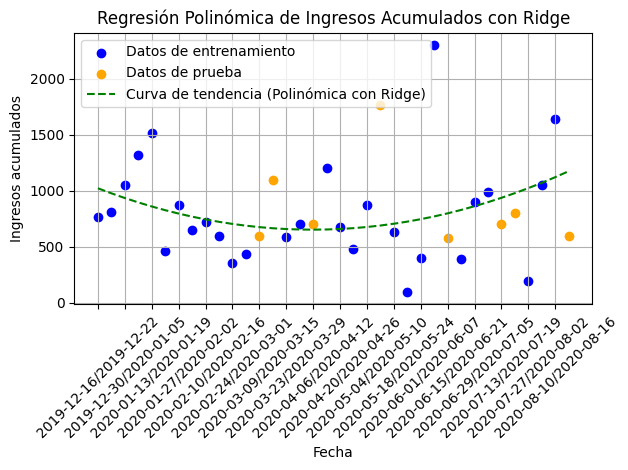

In [106]:
grado = 4
alpha = 10
graficar_ingresos_polinomicos_semanal(df_no_nulos, grado, alpha)

In [107]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def buscar_mejores_parametros(df_no_nulos, grados, alphas):
    """
    Buscar los mejores hiperparámetros para la regresión polinómica con Ridge y graficar todas las combinaciones.
    """
    # Eliminar la primera semana (2019-12-09/2019-12-15) si está presente
    df_no_nulos = df_no_nulos[df_no_nulos['semana'] != '2019-12-09/2019-12-15']

    # Separar los datos en entrenamiento y prueba
    X = df_no_nulos[['semana']].astype(int).values.ravel().reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values
    split_idx = int(len(X) * 0.8)

    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]
    X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)
    resultados = []
    plt.figure(figsize=(15, 10))

    for i, degree in enumerate(grados):
        for j, alpha in enumerate(alphas):

            modelo = make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree), Ridge(alpha=alpha))
            modelo.fit(X_train, y_train)

            y_train_pred = modelo.predict(X_train)
            y_test_pred = modelo.predict(X_test)
            y_pred_total = modelo.predict(X)

            mse = mean_squared_error(y_test, y_test_pred)
            r2_train = r2_score(y_train, y_train_pred)
            r2_test = r2_score(y_test, y_test_pred)
            r2_diff = abs(r2_train - r2_test)

            resultados.append((degree, alpha, mse, r2_train, r2_test, r2_diff))

            plt.subplot(len(grados), len(alphas), i * len(alphas) + j + 1)
            plt.scatter(X_train, y_train, label='Datos de entrenamiento', color='blue', s=10)
            plt.scatter(X_test, y_test, label='Datos de prueba', color='orange', s=10)
            plt.plot(X, y_pred_total, label=f'Grado {degree}, Alpha {alpha}', color='green')
            plt.xticks(rotation=45, fontsize=6)
            plt.yticks(fontsize=6)
            plt.title(f'Grado {degree}, Alpha {alpha}', fontsize=8)

    plt.tight_layout()
    plt.show()

    # Encontrar la mejor combinación según MSE
    best_result = min(resultados, key=lambda x: x[2])
    best_degree, best_alpha, best_mse, best_r2_train, best_r2_test, best_r2_diff = best_result

    print(f"Mejor grado del polinomio: {best_degree}")
    print(f"Mejor alpha para Ridge: {best_alpha}")
    print(f"Mejor MSE: {best_mse}")
    print(f"Mejor R² entrenamiento: {best_r2_train}")
    print(f"Mejor R² prueba: {best_r2_test}")
    print(f"Diferencia R²: {best_r2_diff}")

    return best_degree, best_alpha


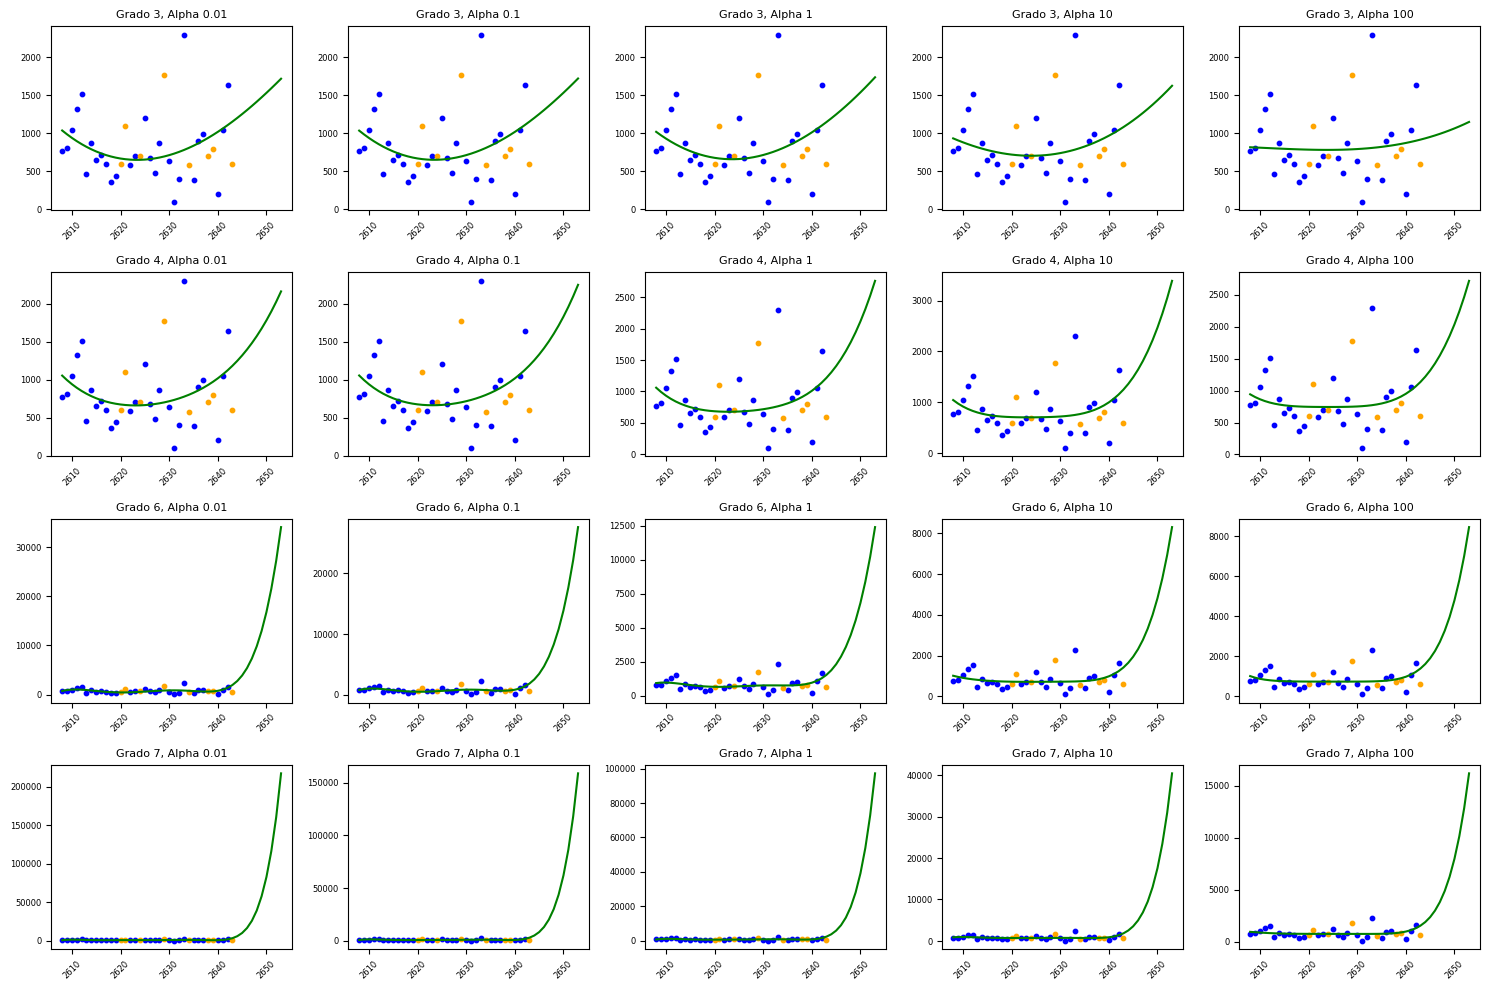

Mejor grado del polinomio: 3
Mejor alpha para Ridge: 100
Mejor MSE: 160409.4463846388
Mejor R² entrenamiento: 0.029707493879613134
Mejor R² prueba: -0.11203593719785565
Diferencia R²: 0.14174343107746878


(3, 100)

In [108]:
grado= [3,4,6,7,]
alpha = [0.01,0.1,1,10,100]

buscar_mejores_parametros(df_no_nulos, grado, alpha)

In [109]:
cohorte.index

PeriodIndex(['2019-11-18/2019-11-24', '2019-12-09/2019-12-15',
             '2019-12-16/2019-12-22', '2019-12-23/2019-12-29',
             '2019-12-30/2020-01-05', '2020-01-06/2020-01-12',
             '2020-01-13/2020-01-19', '2020-01-20/2020-01-26',
             '2020-01-27/2020-02-02', '2020-02-03/2020-02-09',
             '2020-02-10/2020-02-16', '2020-02-17/2020-02-23',
             '2020-02-24/2020-03-01', '2020-03-02/2020-03-08',
             '2020-03-09/2020-03-15', '2020-03-16/2020-03-22',
             '2020-03-23/2020-03-29', '2020-03-30/2020-04-05',
             '2020-04-06/2020-04-12', '2020-04-13/2020-04-19',
             '2020-04-20/2020-04-26', '2020-04-27/2020-05-03',
             '2020-05-04/2020-05-10', '2020-05-11/2020-05-17',
             '2020-05-18/2020-05-24', '2020-05-25/2020-05-31',
             '2020-06-01/2020-06-07', '2020-06-08/2020-06-14',
             '2020-06-15/2020-06-21', '2020-06-22/2020-06-28',
             '2020-06-29/2020-07-05', '2020-07-06/2020-

In [122]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def buscar_mejores_parametros7(df_no_nulos, grado, alpha):
    df_no_nulos = df_no_nulos[df_no_nulos['semana'] != '2019-12-09/2019-12-15']

    X = df_no_nulos[['semana']].astype(int).values.ravel().reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values
    split_idx = int(len(X) * 0.8)

    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]
    X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)
    plt.figure(figsize=(10, 6))  # Tamaño reducido

    modelo = make_pipeline(StandardScaler(), PolynomialFeatures(grado), Ridge(alpha))
    modelo.fit(X_train, y_train)

    y_train_pred = modelo.predict(X_train)
    y_test_pred = modelo.predict(X_test)
    y_pred_total = modelo.predict(X)
    y_pred_int = modelo.predict(X_interp)

    mse = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    plt.scatter(X_train, y_train, label='Datos de entrenamiento', color='blue', s=10)
    plt.scatter(X_test, y_test, label='Datos de prueba', color='orange', s=10)
    plt.plot(X_interp, y_pred_int, label=f'Grado {grado}, Alpha {alpha}', color='green')
    plt.xticks(rotation=45, fontsize=6)
    plt.yticks(fontsize=6)
    plt.title(f'Grado {grado}, Alpha {alpha}', fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

    # Crear un DataFrame con fecha, valores reales y valores predichos
    resultados = pd.DataFrame({
        'Fecha': df_no_nulos['semana'].values,
        'Valor Real': y,
        'Valor Predicho': y_pred_total
    })
    print(resultados)
    return modelo


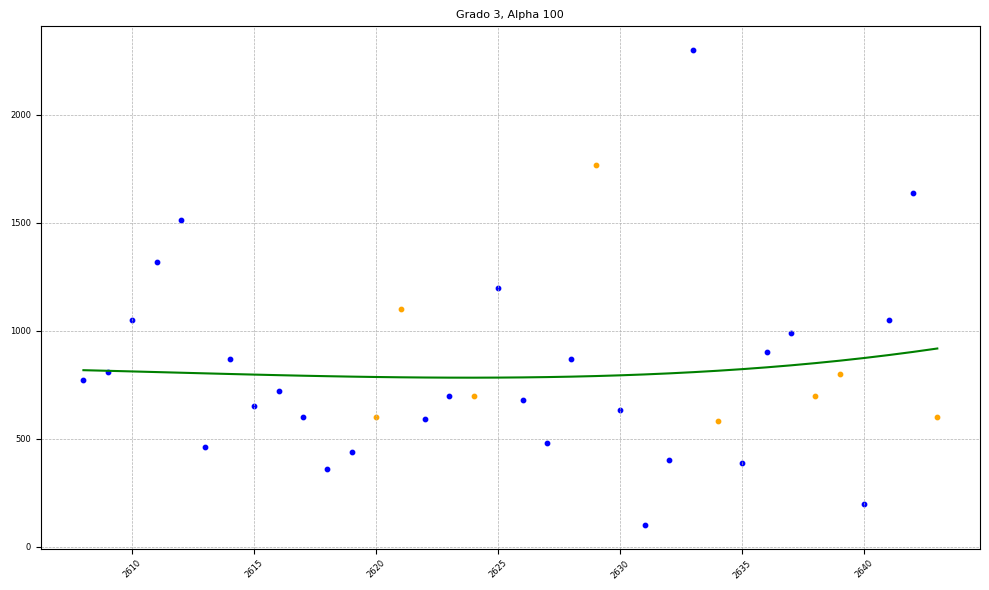

                    Fecha  Valor Real  Valor Predicho
0   2019-12-16/2019-12-22       770.0      817.583440
1   2019-12-23/2019-12-29       810.0      814.748985
2   2019-12-30/2020-01-05      1050.0      811.822144
3   2020-01-06/2020-01-12      1320.0      808.841815
4   2020-01-13/2020-01-19      1515.0      805.846892
5   2020-01-20/2020-01-26       460.0      802.876274
6   2020-01-27/2020-02-02       870.0      799.968855
7   2020-02-03/2020-02-09       650.0      797.163534
8   2020-02-10/2020-02-16       720.0      794.499205
9   2020-02-17/2020-02-23       600.0      792.014766
10  2020-02-24/2020-03-01       360.0      789.749112
11  2020-03-02/2020-03-08       440.0      787.741141
12  2020-03-09/2020-03-15       600.0      786.029748
13  2020-03-16/2020-03-22      1100.0      784.653831
14  2020-03-23/2020-03-29       590.0      783.652284
15  2020-03-30/2020-04-05       700.0      783.064006
16  2020-04-06/2020-04-12       700.0      782.927892
17  2020-04-13/2020-04-19   

In [123]:
grado= 3
alpha = 100

modelo3= buscar_mejores_parametros7(df_no_nulos, grado, alpha)

In [117]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def buscar_mejores_parametros9(ingresos_heatmap, cohorte, grados, alphas):
    try:
        # Modificar el índice para que solo contenga datos antes del "/"
        ingresos_heatmap.index = ingresos_heatmap.index.str.split('/').str[0]

        if cohorte not in ingresos_heatmap.index:
            raise KeyError(f"La cohorte '{cohorte}' no existe en el DataFrame. Cohortes disponibles: {list(ingresos_heatmap.index)}")

        datos_cohorte = ingresos_heatmap.loc[cohorte]
        fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), errors='coerce')
        ingresos = datos_cohorte.values

        imputer = SimpleImputer(strategy='mean')
        ingresos_imputed = imputer.fit_transform(ingresos.reshape(-1, 1)).ravel()

        fechas_no_nan = fechas_cohorte[~np.isnan(ingresos_imputed)]
        ingresos_no_nan = ingresos_imputed[~np.isnan(ingresos_imputed)]

        num_interpolacion = int(0.8 * len(fechas_no_nan))
        dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

        X_train, X_test, y_train, y_test = train_test_split(
            dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion],
            test_size=0.2, random_state=42
        )

        resultados = []
        plt.figure(figsize=(15, 10))

        for i, degree in enumerate(grados):
            for j, alpha in enumerate(alphas):
                modelo = make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree), Ridge(alpha=alpha))
                modelo.fit(X_train, y_train)

                y_train_pred = modelo.predict(X_train)
                y_test_pred = modelo.predict(X_test)
                y_pred_total = modelo.predict(dias_desde_inicio)

                mse = mean_squared_error(y_test, y_test_pred)
                r2_train = r2_score(y_train, y_train_pred)
                r2_test = r2_score(y_test, y_test_pred)
                r2_diff = abs(r2_train - r2_test)

                resultados.append((degree, alpha, mse, r2_train, r2_test, r2_diff))

                plt.subplot(len(grados), len(alphas), i * len(alphas) + j + 1)
                plt.scatter(X_train, y_train, label='Datos de entrenamiento', color='blue', s=10)
                plt.scatter(X_test, y_test, label='Datos de prueba', color='orange', s=10)
                plt.plot(dias_desde_inicio, y_pred_total, label=f'Grado {degree}, Alpha {alpha}', color='green')
                plt.xticks(rotation=45, fontsize=6)
                plt.yticks(fontsize=6)
                plt.title(f'Grado {degree}, Alpha {alpha}', fontsize=8)

        plt.tight_layout()
        plt.show()

        best_result = min(resultados, key=lambda x: x[2])
        best_degree, best_alpha, best_mse, best_r2_train, best_r2_test, best_r2_diff = best_result

        print(f"Mejor grado del polinomio: {best_degree}")
        print(f"Mejor alpha para Ridge: {best_alpha}")
        print(f"Mejor MSE: {best_mse}")
        print(f"Mejor R² entrenamiento: {best_r2_train}")
        print(f"Mejor R² prueba: {best_r2_test}")
        print(f"Diferencia R²: {best_r2_diff}")

        return best_degree, best_alpha

    except KeyError as e:
        print(f"Error: {e}")
    except Exception as e:
        print(f"Error: {e}")

grado= [3,4,7,8,9]
alpha = [0.01,0.1,1,10,100]

buscar_mejores_parametros9(cohorte, '2019-12-09', grado, alpha)

Error: Can only use .str accessor with string values!


In [116]:
def graficar_un_parametro6(ingresos_heatmap, cohorte, degree, alpha):
    datos_cohorte = ingresos_heatmap.loc[cohorte]
    fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
    ingresos = datos_cohorte.values

    fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
    ingresos_no_nan = ingresos[~np.isnan(ingresos)]

    num_interpolacion = int(0.8 * len(fechas_no_nan))
    dias_desde_inicio = (fechas_no_nan - pd.to_datetime('2019-12-09')).days.to_numpy().reshape(-1, 1)

    X_train, X_test, y_train, y_test = train_test_split(
        dias_desde_inicio[:num_interpolacion], ingresos_no_nan[:num_interpolacion],
        test_size=0.2, random_state=42
    )

    modelo = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree),
        Ridge(alpha=alpha)
    )
    modelo.fit(X_train, y_train)

    predicciones_originales = modelo.predict((fechas_cohorte - pd.to_datetime('2019-12-09')).days.to_numpy().reshape(-1, 1))
    std_dev = np.std(y_train - modelo.predict(X_train)) * 0.5  # Multiplicamos para visibilidad

    plt.figure(figsize=(10, 6))
    plt.scatter(fechas_no_nan[:num_interpolacion], ingresos_no_nan[:num_interpolacion], color='blue', label='Datos de entrenamiento')
    plt.scatter(fechas_no_nan[num_interpolacion:], ingresos_no_nan[num_interpolacion:], color='red', label='Datos de extrapolación')
    plt.plot(fechas_cohorte, predicciones_originales, color='green', linewidth=2, linestyle='--', label=f'Predicción (Grado {degree}, Alpha {alpha})')
    plt.fill_between(fechas_cohorte, predicciones_originales - std_dev, predicciones_originales + std_dev, color='green', alpha=0.4, label='Desv. Estándar (3σ)')

    plt.xlabel('Fecha')
    plt.ylabel('Ingresos')
    plt.title(f'Regresión Polinómica (Grado {degree}, Alpha {alpha}) con Desv. Estándar')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return modelo



modelo_6=graficar_un_parametro6(cohorte, '2019-12-09/2019-12-15', 4, 0.1)

KeyError: 'W'

In [115]:

def evaluar_modelos_validacion_cruzada(ingresos_heatmap, cohorte, grados, alpha, cv=5):
    dif_r2 = []
    r2_interpol = []

    for degree in grados:
        datos_cohorte = ingresos_heatmap.loc[cohorte]
        fechas_cohorte = pd.to_datetime(ingresos_heatmap.columns.tolist(), format='%Y-%m')
        ingresos = datos_cohorte.values

        fechas_no_nan = fechas_cohorte[~np.isnan(ingresos)]
        ingresos_no_nan = ingresos[~np.isnan(ingresos)]
        num_interpolacion = int(0.8 * len(fechas_no_nan))
        dias_desde_inicio = (fechas_no_nan - fechas_no_nan.min()).days.to_numpy().reshape(-1, 1)

        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        fold_dif_r2 = []
        fold_r2_interpol = []

        for train_index, test_index in kf.split(dias_desde_inicio):
            X_train, X_test = dias_desde_inicio[train_index], dias_desde_inicio[test_index]
            y_train, y_test = ingresos_no_nan[train_index], ingresos_no_nan[test_index]

            modelo = make_pipeline(
                StandardScaler(),
                PolynomialFeatures(degree=degree),
                Ridge(alpha=alpha)
            )
            modelo.fit(X_train, y_train)

            r2_train = modelo.score(X_train, y_train)
            r2_test = modelo.score(X_test, y_test)

            fold_dif_r2.append(r2_train - r2_test)
            fold_r2_interpol.append(r2_score(y_train, modelo.predict(X_train)))

        dif_r2.append(fold_dif_r2)
        r2_interpol.append(fold_r2_interpol)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].boxplot(dif_r2, widths=0.6, patch_artist=True)
    axes[0].set_xticks(range(1, len(grados)+1))
    axes[0].set_xticklabels(grados)
    axes[0].set_title('Diferencia de R^2 en Validación Cruzada')
    axes[0].set_xlabel('Grado del polinomio')
    axes[0].set_ylabel('Diferencia R^2 (Train - Test)')
    axes[0].grid(True, linestyle='--', alpha=0.6)

    axes[1].boxplot(r2_interpol, widths=0.6, patch_artist=True)
    axes[1].set_xticks(range(1, len(grados)+1))
    axes[1].set_xticklabels(grados)
    axes[1].set_title('R^2 de Interpolación en Validación Cruzada')
    axes[1].set_xlabel('Grado del polinomio')
    axes[1].set_ylabel('R^2 de Interpolación')
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

grados = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
evaluar_modelos_validacion_cruzada(cohorte, '2019-12-09', grados, alpha=0.1, cv=5)

KeyError: 'W'

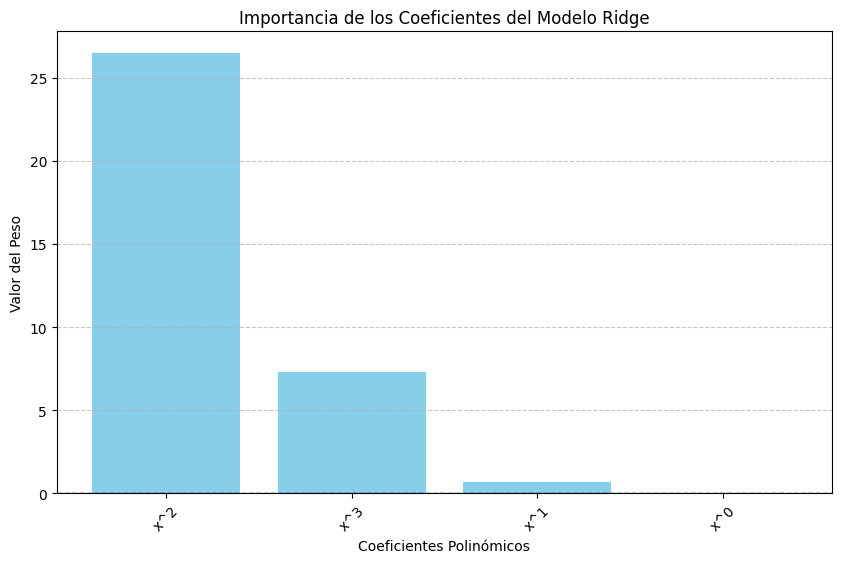

In [124]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def extraer_coeficientes_ridge(modelo):
    """
    Extraer y visualizar los coeficientes del modelo Ridge.
    """
    # 1️⃣ Extraer coeficientes del modelo
    coefs = modelo.named_steps['ridge'].coef_.flatten()

    # 2️⃣ Crear etiquetas para cada coeficiente
    feature_labels = [f"x^{i}" for i in range(len(coefs))]

    # 3️⃣ Crear un DataFrame ordenado por magnitud del coeficiente
    df_coefs = pd.DataFrame({"Feature": feature_labels, "Peso": coefs})
    df_coefs["Peso Abs"] = np.abs(df_coefs["Peso"])
    df_coefs = df_coefs.sort_values(by="Peso Abs", ascending=False)

    # 4️⃣ Graficar los coeficientes
    plt.figure(figsize=(10, 6))
    plt.bar(df_coefs["Feature"], df_coefs["Peso"], color="skyblue")
    plt.axhline(0, color="black", linewidth=1, linestyle="--")

    # Configuración del gráfico
    plt.xlabel("Coeficientes Polinómicos")
    plt.ylabel("Valor del Peso")
    plt.title("Importancia de los Coeficientes del Modelo Ridge")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Ejemplo de uso:
extraer_coeficientes_ridge(modelo3)

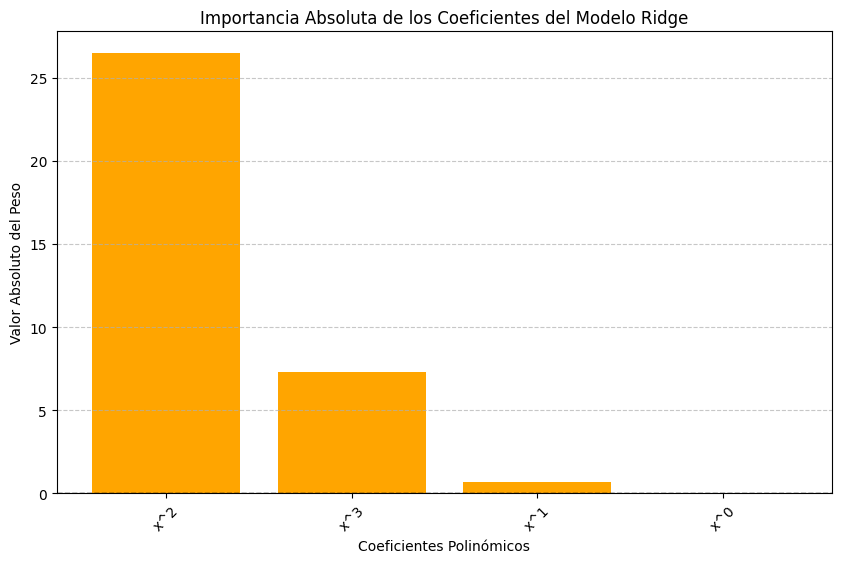

In [126]:
def extraer_coeficientes_absolutos_ridge(modelo):
    """
    Extraer y visualizar los valores absolutos de los coeficientes del modelo Ridge.
    """
    # 1️⃣ Obtener los valores absolutos de los coeficientes
    coefs_abs = np.abs(modelo.named_steps['ridge'].coef_.flatten())

    # 2️⃣ Crear etiquetas para cada coeficiente polinómico
    feature_labels = [f"x^{i}" for i in range(len(coefs_abs))]

    # 3️⃣ Crear un DataFrame y ordenarlo por magnitud del coeficiente
    df_coefs_abs = pd.DataFrame({"Feature": feature_labels, "Peso Abs": coefs_abs})
    df_coefs_abs = df_coefs_abs.sort_values(by="Peso Abs", ascending=False)

    # 4️⃣ Graficar los coeficientes absolutos
    plt.figure(figsize=(10, 6))
    plt.bar(df_coefs_abs["Feature"], df_coefs_abs["Peso Abs"], color="orange")
    plt.axhline(0, color="black", linewidth=1, linestyle="--")

    # Configuración del gráfico
    plt.xlabel("Coeficientes Polinómicos")
    plt.ylabel("Valor Absoluto del Peso")
    plt.title("Importancia Absoluta de los Coeficientes del Modelo Ridge")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()
extraer_coeficientes_absolutos_ridge(modelo3)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def graficar_alpha_grado2(df_no_nulos, grado, alpha):
    """
    Graficar un modelo con un único grado y alpha.
    """
    df_no_nulos = df_no_nulos[df_no_nulos['semana'] != '2019-12-09/2019-12-15']
    X = df_no_nulos[['semana']].astype(int).values.ravel().reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values

    split_idx = int(len(X) * 0.8)

    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]
    X_train1, X_test1, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.4, random_state=42)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train1)
    X_test_scaled = scaler.transform(X_test1)
    X_scaled = scaler.transform(X)

    modelo = make_pipeline(PolynomialFeatures(degree=grado), Ridge(alpha=alpha))
    modelo.fit(X_train_scaled, y_train)


    # Realizar predicciones
    y_train_pred = modelo.predict(X_train_scaled)
    y_test_pred = modelo.predict(X_test_scaled)
    y_pred_total = modelo.predict(X_scaled)
    # Mostrar métricas
    mse = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)

    print(f"Grado: {grado}, Alpha: {alpha}")
    print(f"MSE: {mse}")
    print(f"R² entrenamiento: {r2_train}")
    print(f"R² prueba: {r2_test}")

    # Graficar resultados
    plt.figure(figsize=(12, 7))
    plt.scatter(X_train1, y_train, label='Entrenamiento', color='blue', s=20)
    plt.scatter(X_test1, y_test, label='Prueba', color='orange', s=20)
    plt.plot(X, y_pred_total, label=f'Modelo (Grado {grado}, Alpha {alpha})', color='green')

    plt.xlabel('Semanas')
    plt.ylabel('Valores Acumulados')
    plt.title(f'Modelo Ridge (Grado {grado}, Alpha {alpha})')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [ ]:
graficar_alpha_grado2(df_no_nulos,3 , 100)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def graficar_alpha_grado3(df_no_nulos, grado, alpha):
    """
    Graficar un modelo específico con un único grado y alpha en Ridge Regression,
    incluyendo una sombra basada en la desviación estándar.
    """
    # Eliminar la primera semana (2019-12-09/2019-12-15) si está presente
    df_no_nulos = df_no_nulos[df_no_nulos['semana'] != '2019-12-09/2019-12-15']

    # Separar los datos en entrenamiento y prueba
    X = df_no_nulos[['semana']].astype(int).values.ravel().reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values
    split_idx = int(len(X) * 0.8)

    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]
    X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.4, random_state=42)

    # Aplicar estandarización
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_scaled = scaler.transform(X)
    X_extrap_scaled = scaler.transform(X_extrap)

    modelo = make_pipeline(PolynomialFeatures(degree=grado), Ridge(alpha=alpha))
    modelo.fit(X_train_scaled, y_train)

    y_train_pred = modelo.predict(X_train_scaled)
    y_test_pred = modelo.predict(X_test_scaled)
    y_pred_total = modelo.predict(X_scaled)
    y_extrap_pred = modelo.predict(X_extrap_scaled)

    mse = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    r2_diff = abs(r2_train - r2_test)

    # Calcular la desviación estándar de las predicciones
    std_dev = np.std(y_pred_total)

    print(f"Grado: {grado}, Alpha: {alpha}")
    print(f"MSE: {mse}")
    print(f"R² entrenamiento: {r2_train}")
    print(f"R² prueba: {r2_test}")
    print(f"Diferencia R²: {r2_diff}")

    plt.figure(figsize=(8, 6))
    plt.scatter(X_train_scaled, y_train, label='Datos de entrenamiento', color='blue', s=10)
    plt.scatter(X_test_scaled, y_test, label='Datos de prueba', color='orange', s=10)
    plt.scatter(X_extrap_scaled, y_extrap, color='orange', label='Datos originales (y_extrap)', s=20)

    plt.plot(X_scaled, y_pred_total, label=f'Grado {grado}, Alpha {alpha}', color='green')

    # Agregar sombra con la desviación estándar
    plt.fill_between(X_scaled.flatten(), y_pred_total - std_dev, y_pred_total + std_dev, color='green', alpha=0.2)

    plt.xticks(X_scaled.flatten()[::2], df_no_nulos['semana'].astype(str).values[::2], rotation=45)
    plt.xlabel('Fecha')
    plt.ylabel('Ingresos acumulados')
    plt.title(f'Regresión Polinómica con Sombra (Grado {grado}, Alpha {alpha})')
    plt.legend()
    plt.grid()
    plt.show()

In [ ]:
graficar_alpha_grado3(df_no_nulos, 3 , 100)

VALIDACIÓN CRUZADA CON RIDGE

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def validacion_cruzada_ridge(df_no_nulos, grados, alpha=100):
    """
    Realizar validación cruzada con Ridge Regression para diferentes grados de polinomio
    y visualizar la distribución de RMSE y R² en boxplots con escala logarítmica.
    """
    # Eliminar la primera semana (2019-12-09/2019-12-15) si está presente
    df_no_nulos = df_no_nulos[df_no_nulos['semana'] != '2019-12-09/2019-12-15']

    # Extraer datos
    X = df_no_nulos[['semana']].astype(int).values.reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values
    split_idx = int(len(X) * 0.8)
    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]
    # Aplicar estandarización
    scaler = StandardScaler()
    X_scaled= scaler.fit_transform(X_interp)
    # Configurar validación cruzada con K-Fold
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    # Almacenar resultados para los boxplots de RMSE y R²
    rmse_scores = {degree: [] for degree in grados}
    r2_scores = {degree: [] for degree in grados}

    # Iterar sobre cada grado de polinomio
    for degree in grados: # Aplicar transformación polinómica
        model = make_pipeline(StandardScaler(), PolynomialFeatures(grado), Ridge(alpha))

        # Validación cruzada con RMSE y R²
        mse_cv_scores = cross_val_score(model, X_scaled, y_interp, cv=kf, scoring=make_scorer(mean_squared_error))
        r2_cv_scores = cross_val_score(model, X_scaled, y_interp, cv=kf, scoring=make_scorer(r2_score))

        # Guardar RMSE (Raíz de MSE) y R²
        rmse_scores[degree] = np.sqrt(np.abs(mse_cv_scores))  # Convertir MSE a RMSE
        r2_scores[degree] = np.abs(r2_cv_scores)  # Convertir R² a valores absolutos para escala logarítmica

    # Crear DataFrames para los boxplots
    df_rmse = pd.DataFrame.from_dict(rmse_scores, orient="index").T
    df_r2 = pd.DataFrame.from_dict(r2_scores, orient="index").T

    # 🔹 Graficar boxplots de RMSE y R² en escala logarítmica
    plt.figure(figsize=(14, 6))

    # Boxplot de R²
    plt.subplot(1, 2, 1)
    df_rmse.boxplot()
    plt.yscale("log")  # Aplicar escala logarítmica
    plt.xlabel("Grado del Polinomio")
    plt.ylabel("RMSE (Escala Log)")
    plt.title("Distribución de RMSE en Validación Cruzada (Escala Logarítmica)")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    # Boxplot de R²
    plt.subplot(1, 2, 2)
    df_r2.boxplot()
    plt.yscale("log")  # Aplicar escala logarítmica
    plt.xlabel("Grado del Polinomio")
    plt.ylabel("R² (Escala Log)")
    plt.title("Distribución de R² en Validación Cruzada (Escala Logarítmica)")
    plt.grid(True, which="both", linestyle="--", linewidth=0.5)

    plt.show()



In [ ]:
grados2 = [1,2,3,4,5,6,9,10,11,12,12,13,14,15]
validacion_cruzada_ridge(df_no_nulos,grados2)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def graficar_alpha_grado2_con_prediccion(df_no_nulos, grado, alpha):
    """
    Graficar un modelo con predicciones a 8 semanas futuras, mostrando fechas legibles en el eje X.
    """
    df_no_nulos = df_no_nulos[df_no_nulos['semana'] != '2019-12-09/2019-12-15']

    X = df_no_nulos[['semana']].astype(int).values.ravel().reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values
    split_idx = int(len(X) * 0.8)

    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]
    X_train, X_test, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.4, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    X_scaled = scaler.transform(X)
    X_extrap_scaled = scaler.transform(X_extrap)

    semanas_futuras = np.arange(X.max() + 1, X.max() + 16).reshape(-1, 1)
    semanas_futuras_scaled = scaler.transform(semanas_futuras)

    modelo = make_pipeline(PolynomialFeatures(degree=grado), Ridge(alpha=alpha))
    modelo.fit(X_train_scaled, y_train)

    y_train_pred= modelo.predict(X_train_scaled)
    y_test_pred = modelo.predict(X_test_scaled)
    y_pred_total = modelo.predict(X_scaled)
    y_pred_futuras = modelo.predict(semanas_futuras_scaled)
    y_extrap_pred = modelo.predict(X_extrap_scaled)
    std_dev = np.std(y_pred_total)

    todas_semanas = np.concatenate([X, semanas_futuras]).flatten()
    todas_labels = list(df_no_nulos['semana'].astype(str)) + [f"2020-10-25/2020-11-1 + {i}" for i in range(1, 16)]
    mse = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    r2_diff = abs(r2_train - r2_test)
    print(f"Diferencia R²: {r2_train} {r2_test}   {r2_diff}")
    #interpolante
    from scipy.interpolate import interp1d


    X_pred = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
    y_pred = modelo.predict(scaler.transform(X_pred))

    # Calcular el interpolante lineal a partir de las predicciones
    interpolante = interp1d(X_pred.flatten(), y_pred, kind='linear', fill_value="extrapolate")

    # Generar valores interpolados
    X_interpol = np.linspace(X.min(), X.max(), 300)
    y_interpol = interpolante(X_interpol)

    # Mostrar tabla con valores interpolados
    df_interpol = pd.DataFrame({
        'Semana': X_interpol,
        'Interpolante': y_interpol
    })
    print("\n📊 Tabla de Valores Interpolados:")
    print(df_interpol)

    # Graficar resultados
    plt.figure(figsize=(8, 5))
    plt.scatter(X, y, color='blue', label='Datos originales')
    plt.plot(X_pred, y_pred, color='green', linestyle='--', label='Modelo de Regresión')
    plt.plot(X_interpol, y_interpol, color='orange', linestyle='-', label='Interpolante')
    plt.xlabel('Semana')
    plt.ylabel('Ingresos acumulados')
    plt.title('Modelo y su Interpolante (Grado 4, Alpha 100)')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(14, 7))
    plt.plot(todas_semanas, np.concatenate([y_pred_total, y_pred_futuras]), label=f'Modelo (Grado {grado}, Alpha {alpha})', color='green')
    plt.scatter(X_train, y_train, label='Entrenamiento', color='blue', s=15)
    plt.scatter(X_extrap, y_extrap, color='orange', label='Datos originales (y_extrap)', s=20)

    plt.scatter(X_test, y_test, label='Prueba', color='orange', s=15)
    plt.scatter(semanas_futuras, y_pred_futuras, label='Futuras (8 semanas)', color='red', marker='x', s=30)

    plt.xticks(todas_semanas[::2], todas_labels[::2], rotation=45, fontsize=7, ha='right')

    plt.xlabel('Fecha')
    plt.ylabel('Ingresos acumulados')
    plt.title(f'Predicciones con Fechas Legibles (Grado {grado}, Alpha {alpha})')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return modelo

In [ ]:
modelo_4= graficar_alpha_grado2_con_prediccion(df_no_nulos, 6, 100)

In [ ]:
modelo_4= graficar_alpha_grado2_con_prediccion(df_no_nulos,2, 0.1)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def extraer_coeficientes_ridge(modelo):
    """
    Extraer y visualizar los coeficientes del modelo Ridge.
    """
    # 1️⃣ Extraer coeficientes del modelo
    coefs = modelo.named_steps['ridge'].coef_.flatten()

    # 2️⃣ Crear etiquetas para cada coeficiente
    feature_labels = [f"x^{i}" for i in range(len(coefs))]

    # 3️⃣ Crear un DataFrame ordenado por magnitud del coeficiente
    df_coefs = pd.DataFrame({"Feature": feature_labels, "Peso": coefs})
    df_coefs["Peso Abs"] = np.abs(df_coefs["Peso"])
    df_coefs = df_coefs.sort_values(by="Peso Abs", ascending=False)

    # 4️⃣ Graficar los coeficientes
    plt.figure(figsize=(10, 6))
    plt.bar(df_coefs["Feature"], df_coefs["Peso"], color="skyblue")
    plt.axhline(0, color="black", linewidth=1, linestyle="--")

    # Configuración del gráfico
    plt.xlabel("Coeficientes Polinómicos")
    plt.ylabel("Valor del Peso")
    plt.title("Importancia de los Coeficientes del Modelo Ridge")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

# Ejemplo de uso:


In [ ]:
 extraer_coeficientes_ridge(modelo_4)


In [ ]:
def extraer_coeficientes_absolutos_ridge(modelo):
    """
    Extraer y visualizar los valores absolutos de los coeficientes del modelo Ridge.
    """
    # 1️⃣ Obtener los valores absolutos de los coeficientes
    coefs_abs = np.abs(modelo.named_steps['ridge'].coef_.flatten())

    # 2️⃣ Crear etiquetas para cada coeficiente polinómico
    feature_labels = [f"x^{i}" for i in range(len(coefs_abs))]

    # 3️⃣ Crear un DataFrame y ordenarlo por magnitud del coeficiente
    df_coefs_abs = pd.DataFrame({"Feature": feature_labels, "Peso Abs": coefs_abs})
    df_coefs_abs = df_coefs_abs.sort_values(by="Peso Abs", ascending=False)

    # 4️⃣ Graficar los coeficientes absolutos
    plt.figure(figsize=(10, 6))
    plt.bar(df_coefs_abs["Feature"], df_coefs_abs["Peso Abs"], color="orange")
    plt.axhline(0, color="black", linewidth=1, linestyle="--")

    # Configuración del gráfico
    plt.xlabel("Coeficientes Polinómicos")
    plt.ylabel("Valor Absoluto del Peso")
    plt.title("Importancia Absoluta de los Coeficientes del Modelo Ridge")
    plt.xticks(rotation=45)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()

In [ ]:
extraer_coeficientes_absolutos_ridge(modelo_4)

In [ ]:
#interpolante
from scipy.interpolate import interp1d


X_pred = np.linspace(X.min(), X.max(), 200).reshape(-1, 1)
y_pred = modelo4.predict(scaler.transform(X_pred))

# Calcular el interpolante lineal a partir de las predicciones
interpolante = interp1d(X_pred.flatten(), y_pred, kind='linear', fill_value="extrapolate")

# Generar valores interpolados
X_interpol = np.linspace(X.min(), X.max(), 300)
y_interpol = interpolante(X_interpol)

# Mostrar tabla con valores interpolados
df_interpol = pd.DataFrame({
    'Semana': X_interpol,
    'Interpolante': y_interpol
})
print("\n📊 Tabla de Valores Interpolados:")
print(df_interpol)

# Graficar resultados
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='blue', label='Datos originales')
plt.plot(X_pred, y_pred, color='green', linestyle='--', label='Modelo de Regresión')
plt.plot(X_interpol, y_interpol, color='orange', linestyle='-', label='Interpolante')
plt.xlabel('Semana')
plt.ylabel('Ingresos acumulados')
plt.title('Modelo y su Interpolante (Grado 4, Alpha 100)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def buscar_mejores_parametros_con_prediccion(df_no_nulos, grados, alphas):
    """
    Buscar los mejores hiperparámetros para la regresión polinómica con Ridge,
    graficar todas las combinaciones y predecir 8 semanas futuras.
    """
    # Eliminar la primera semana (2019-12-09/2019-12-15) si está presente
    df_no_nulos = df_no_nulos[df_no_nulos['semana'] != '2019-12-09/2019-12-15']

    # Separar los datos en entrenamiento y prueba
    X = df_no_nulos[['semana']].astype(int).values.ravel().reshape(-1, 1)
    y = df_no_nulos['Acumulado'].values

    split_idx = int(len(X) * 0.8)
    X_interp, X_extrap = X[:split_idx], X[split_idx:]
    y_interp, y_extrap = y[:split_idx], y[split_idx:]
    X_train1, X_test1, y_train, y_test = train_test_split(X_interp, y_interp, test_size=0.2, random_state=42)

    resultados = []
    plt.figure(figsize=(15, 10))

    # Generar semanas futuras (8 semanas a partir de '2020-10-25/2020-11-1')
    semanas_futuras = np.arange(X.max() + 1, X.max() + 9).reshape(-1, 1)

    for i, degree in enumerate(grados):
        for j, alpha in enumerate(alphas):
            modelo = make_pipeline(StandardScaler(), PolynomialFeatures(degree=degree), Ridge(alpha=alpha))
            modelo.fit(X_train1, y_train)

            y_train_pred = modelo.predict(X_train1)
            y_test_pred = modelo.predict(X_test1)
            y_pred_total = modelo.predict(X)
            y_pred_futuras = modelo.predict(semanas_futuras)

            mse = mean_squared_error(y_test, y_test_pred)
            r2_train = r2_score(y_train, y_train_pred)
            r2_test = r2_score(y_test, y_test_pred)
            r2_diff = abs(r2_train - r2_test)

            resultados.append((degree, alpha, mse, r2_train, r2_test, r2_diff))

            plt.subplot(len(grados), len(alphas), i * len(alphas) + j + 1)
            plt.scatter(X_train1, y_train, label='Datos de entrenamiento', color='blue', s=10)
            plt.scatter(X_test1, y_test, label='Datos de prueba', color='orange', s=10)
            plt.scatter(X_extrap, y_extrap, color='orange', label='Datos originales (y_extrap)', s=20)

            plt.plot(X, y_pred_total, label=f'Modelo (Grado {degree}, Alpha {alpha})', color='green')
            plt.scatter(semanas_futuras, y_pred_futuras, label='Predicciones futuras', color='red', marker='x')
            plt.xticks(rotation=45, fontsize=6)
            plt.yticks(fontsize=6)
            plt.title(f'Grado {degree}, Alpha {alpha}', fontsize=8)
            plt.legend(fontsize=6)

    plt.tight_layout()
    plt.show()

    best_result = min(resultados, key=lambda x: x[2])
    best_degree, best_alpha, best_mse, best_r2_train, best_r2_test, best_r2_diff = best_result

    print(f"Mejor grado del polinomio: {best_degree}")
    print(f"Mejor alpha para Ridge: {best_alpha}")
    print(f"Mejor MSE: {best_mse}")
    print(f"Mejor R² entrenamiento: {best_r2_train}")
    print(f"Mejor R² prueba: {best_r2_test}")
    print(f"Diferencia R²: {best_r2_diff}")


In [ ]:
buscar_mejores_parametros_con_prediccion(df_no_nulos, [2,3,4,6,8,9], [0.001,0.1, 1, 10])